# Annapurdna 1.0

In [1]:
import os
import pandas as pd
folder_path=r'C:\Users\tempe\Desktop\prototype'
file_path=r'Anyapurna_Final_Training_Data.csv'
full_path=os.path.join(folder_path,file_path)
df=pd.read_csv(full_path)
print(df.head())

           State        District    Crop     Year Season  Area Area Units  \
0  Uttar Pradesh       ALLAHABAD  Barley  2001-02   Rabi  6557    Hectare   
1  Uttar Pradesh       ALLAHABAD  Barley  2002-03   Rabi  6095    Hectare   
2  Uttar Pradesh       ALLAHABAD  Barley  2003-04   Rabi  6129    Hectare   
3  Uttar Pradesh  AMBEDKAR NAGAR  Barley  2001-02   Rabi   874    Hectare   
4  Uttar Pradesh  AMBEDKAR NAGAR  Barley  2002-03   Rabi   918    Hectare   

   Production Production Units     Yield Risk_Level  
0       10019           Tonnes  1.527985     Stable  
1        7844           Tonnes  1.286957     Stable  
2        8074           Tonnes  1.317344     Stable  
3        2077           Tonnes  2.376430     Stable  
4        2245           Tonnes  2.445534     Stable  


In [2]:
cols_to_drop=['State','Area Units','Production','Production Units','Risk_Level']
df=df.drop(columns=cols_to_drop)

In [3]:
print(df.head())

         District    Crop     Year Season  Area     Yield
0       ALLAHABAD  Barley  2001-02   Rabi  6557  1.527985
1       ALLAHABAD  Barley  2002-03   Rabi  6095  1.286957
2       ALLAHABAD  Barley  2003-04   Rabi  6129  1.317344
3  AMBEDKAR NAGAR  Barley  2001-02   Rabi   874  2.376430
4  AMBEDKAR NAGAR  Barley  2002-03   Rabi   918  2.445534


In [4]:
df['Season'] = df['Season'].replace({'Rabi': 1, 'Kharif': 0})
print(df.head())

         District    Crop     Year Season  Area     Yield
0       ALLAHABAD  Barley  2001-02      1  6557  1.527985
1       ALLAHABAD  Barley  2002-03      1  6095  1.286957
2       ALLAHABAD  Barley  2003-04      1  6129  1.317344
3  AMBEDKAR NAGAR  Barley  2001-02      1   874  2.376430
4  AMBEDKAR NAGAR  Barley  2002-03      1   918  2.445534


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   District  2600 non-null   object 
 1   Crop      2600 non-null   object 
 2   Year      2600 non-null   object 
 3   Season    2600 non-null   object 
 4   Area      2600 non-null   int64  
 5   Yield     2600 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 122.0+ KB
None


In [6]:
df['Yield'].describe()

count    2600.000000
mean        1.921406
std         0.821362
min         0.282353
25%         1.159844
50%         2.038992
75%         2.501943
max         4.375000
Name: Yield, dtype: float64

<Axes: >

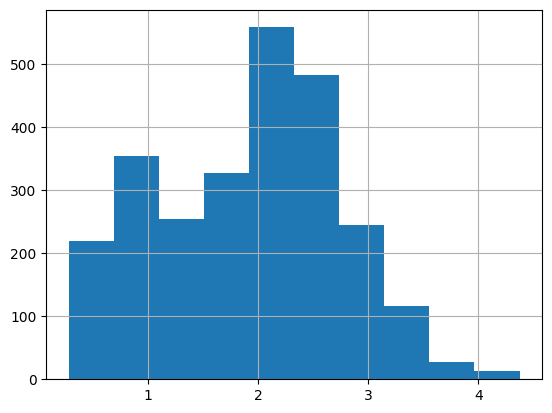

In [7]:
df['Yield'].hist()

In [8]:
df.groupby('Crop')['Yield'].mean()

Crop
Barley               2.050537
Rapeseed &Mustard    0.828894
Rice                 2.125418
Wheat                2.640808
Name: Yield, dtype: float64

In [11]:

df['Year'] = df['Year'].apply(lambda x: int(x.split('-')[0]))


AttributeError: 'int' object has no attribute 'split'

In [12]:
print(df['Year'].head())

0    2001
1    2002
2    2003
3    2001
4    2002
Name: Year, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X=df.drop(columns='Yield')

In [15]:
y=df['Yield']

In [16]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

In [17]:
from sklearn.pipeline import Pipeline

In [18]:
from category_encoders.target_encoder import TargetEncoder

In [19]:
from xgboost import XGBRegressor

In [20]:
estimators = [
    ('encoder', TargetEncoder()),
    ('reg', XGBRegressor(random_state=8))
]

In [21]:
pipe = Pipeline(steps=estimators)

In [22]:
print(pipe)

Pipeline(steps=[('encoder', TargetEncoder()),
                ('reg',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_con

In [23]:
from skopt import BayesSearchCV

In [24]:
from skopt.space import Real, Categorical, Integer

In [25]:
search_space={
    'reg__max_depth':Integer(2,8),
    'reg__learning_rate':Real(0.001, 1.0, prior='log-uniform'),
    'reg__subsample':Real(0.5,1.0),
    'reg__colsample_bytree':Real(0.5,1.0),
    'reg__colsample_bylevel':Real(0.5,1.0),
    'reg__colsample_bynode':Real(0.5,1.0),
    'reg__reg_alpha':Real(0.0,10.0),
    'reg__reg_lambda':Real(0.0,10.0),
    'reg__gamma':Real(0.0,10.0)
}

In [26]:
opt = BayesSearchCV(pipe, search_space, cv=3, n_iter=50, scoring='neg_root_mean_squared_error', random_state=8)

In [27]:
opt.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'reg__colsample_bylevel': Real(low=0.5,...m='normalize'), 'reg__colsample_bynode': Real(low=0.5,...m='normalize'), 'reg__colsample_bytree': Real(low=0.5,...m='normalize'), 'reg__gamma': Real(low=0.0,...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [28]:
opt.best_estimator_

,steps,"[('encoder', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,"['District', 'Crop', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [29]:
opt.best_score_

np.float64(-0.2627928488053148)

In [30]:
opt.score(X_test, y_test)

-0.23756381359731318

In [31]:
opt.predict(X_test)

array([1.8697586 , 1.5596153 , 1.9777386 , 2.864197  , 2.2371666 ,
       2.2731378 , 0.8312247 , 1.8921432 , 2.5465841 , 2.8824873 ,
       1.9676796 , 2.428765  , 3.239025  , 2.4802747 , 2.6392305 ,
       1.6306278 , 1.9735007 , 2.2379658 , 0.7035416 , 0.94505763,
       2.1531093 , 0.6516397 , 1.2381396 , 0.8483728 , 2.368483  ,
       0.9181726 , 2.5590782 , 2.2323809 , 3.0378513 , 0.94381803,
       3.0794382 , 2.0370207 , 2.3171024 , 1.6159239 , 1.8201396 ,
       3.015531  , 0.89850247, 2.30897   , 2.1701674 , 0.7509889 ,
       2.0359821 , 1.9924617 , 2.3493183 , 0.78658086, 2.6825438 ,
       3.2025146 , 2.0759766 , 2.2070131 , 2.0461602 , 3.042306  ,
       0.9377026 , 2.0264902 , 0.9074673 , 2.027647  , 2.270068  ,
       2.825551  , 2.0091052 , 0.7122949 , 0.8504513 , 1.9991685 ,
       2.5790715 , 2.2345216 , 2.931847  , 3.0081573 , 3.3945296 ,
       1.8866612 , 2.144391  , 0.52685225, 2.1783786 , 2.3068569 ,
       3.249275  , 2.0250216 , 1.2584605 , 2.1808257 , 1.28415

In [32]:
opt.best_estimator_.steps

[('encoder', TargetEncoder(cols=['District', 'Crop', 'Season'])),
 ('reg',
  XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=1.0, colsample_bynode=1.0,
               colsample_bytree=0.6087218970485626, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=0.0, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.17586038117012714,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=8, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...))]

In [33]:
from xgboost import plot_importance

In [34]:
xgboost_step = opt.best_estimator_.steps[1]

In [35]:
xgboost_model = xgboost_step[1]

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

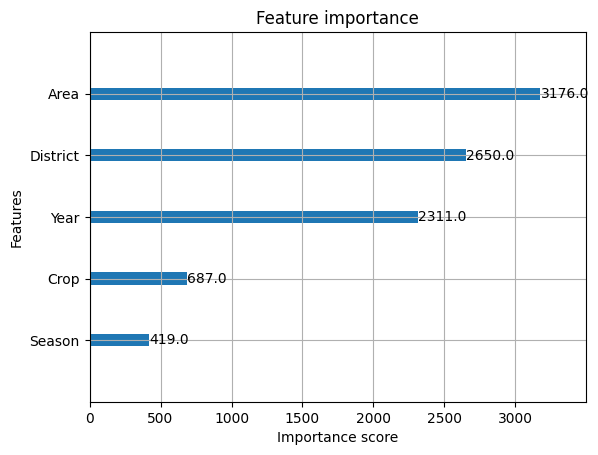

In [36]:
plot_importance(xgboost_model)